# Лабораторная работа 4 — Визуализация данных

**Дисциплина:** Машинное обучение  
**Датасет:** GTZAN Genre Collection (features_30_sec.csv)  
**Библиотеки:** Matplotlib, Seaborn, Plotly, Pandas

## Цель работы

Освоить основные инструменты визуализации данных в Python — библиотеки Matplotlib, Seaborn и Plotly — и применить их для разведочного анализа (EDA) аудиодатасета GTZAN.

## Теоретическое введение

### Разведочный анализ данных (EDA)

**Разведочный анализ данных** (Exploratory Data Analysis, EDA) — это подход к анализу наборов данных, целью которого является выявление основных характеристик данных, обнаружение закономерностей, аномалий и проверка предположений с помощью статистических методов и визуализации. EDA является обязательным этапом любого проекта в области машинного обучения и data science.

Основные цели EDA:
- **Понимание структуры данных** — типы переменных, размерность, наличие пропусков
- **Выявление аномалий и выбросов** — значения, значительно отклоняющиеся от основной массы данных
- **Идентификация связей и корреляций** — взаимозависимости между признаками
- **Подготовка данных** — формирование гипотез для дальнейшего моделирования

### Типы визуализаций и их назначение

| Тип графика | Назначение | Когда использовать |
|------------|-----------|--------------------|
| **Scatter plot** | Отображение связи между двумя переменными | Поиск корреляций, кластеров |
| **Гистограмма** | Распределение одной переменной | Оценка формы распределения, модальности |
| **Box plot** | Статистическое описание + выбросы | Сравнение распределений между группами |
| **Heatmap** | Матрица зависимостей | Корреляционный анализ всех пар признаков |
| **Violin plot** | Распределение + плотность | Более детальное сравнение групп, чем box plot |
| **Pair plot** | Все парные зависимости | Обзорный анализ небольшого числа признаков |
| **Bar chart** | Сравнение категорий | Средние значения, частоты по группам |
| **Pie chart** | Доли целого | Пропорции категорий в датасете |

### Библиотеки визуализации в Python

**Matplotlib** — базовая библиотека визуализации. Основана на концепции объектов Figure (полотно) и Axes (области рисования). Предоставляет полный контроль над каждым элементом графика, но требует больше кода для красивого оформления.

**Seaborn** — высокоуровневая надстройка над Matplotlib. Предоставляет удобные функции для статистической визуализации: heatmap, pairplot, violinplot, displot. Автоматически применяет эстетичные стили.

**Plotly** — библиотека для создания интерактивных графиков. Графики поддерживают hover-подсказки, масштабирование, панорамирование. Особенно полезна для презентаций и дашбордов.

### Корреляция и тепловая карта

**Коэффициент корреляции Пирсона** измеряет линейную зависимость между двумя переменными. Значения от -1 (полная отрицательная корреляция) до +1 (полная положительная корреляция), 0 — отсутствие линейной связи. Тепловая карта корреляционной матрицы позволяет визуально обнаружить сильно и слабо связанные признаки.

### Выбросы и метод IQR

**Выброс** — наблюдение, значительно отличающееся от остальных данных. Для обнаружения выбросов используется **метод межквартильного размаха (IQR)**:
- $IQR = Q_3 - Q_1$
- Нижняя граница: $Q_1 - 1.5 \cdot IQR$
- Верхняя граница: $Q_3 + 1.5 \cdot IQR$

Значения за пределами этих границ считаются выбросами и отображаются на boxplot отдельными точками.

## Загрузка и описание данных

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print('Библиотеки загружены')

Библиотеки загружены


In [95]:
df = pd.read_csv('../../datasets/gtzan/features_3_sec.csv')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Размер датасета: 9990 строк, 60 столбцов


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9990 entries, 0 to 9989
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 9990 non-null   object 
 1   length                   9990 non-null   int64  
 2   chroma_stft_mean         9990 non-null   float64
 3   chroma_stft_var          9990 non-null   float64
 4   rms_mean                 9990 non-null   float64
 5   rms_var                  9990 non-null   float64
 6   spectral_centroid_mean   9990 non-null   float64
 7   spectral_centroid_var    9990 non-null   float64
 8   spectral_bandwidth_mean  9990 non-null   float64
 9   spectral_bandwidth_var   9990 non-null   float64
 10  rolloff_mean             9990 non-null   float64
 11  rolloff_var              9990 non-null   float64
 12  zero_crossing_rate_mean  9990 non-null   float64
 13  zero_crossing_rate_var   9990 non-null   float64
 14  harmony_mean            

In [97]:
# Числовые признаки (исключаем filename и label)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('length')  # length одинаковый для всех, неинформативен
print(f'Числовых признаков для анализа: {len(numeric_cols)}')
df[numeric_cols].describe().round(3)

Числовых признаков для анализа: 57


,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,rolloff_var,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
count,9990.000,9990.000,9990.000,9990.000,9990.000,9990.000,9990.000,9990.000,9990.000,9.990000e+03,...,9990.000,9990.000,9990.000,9990.000,9990.000,9990.000,9990.000,9990.000,9990.000,9990.000
mean,0.380,0.085,0.131,0.003,2199.219,416672.699,2241.386,118271.113,4566.077,1.628790e+06,...,1.448,49.989,-4.199,51.963,0.740,52.489,-2.497,54.974,-0.918,57.323
std,0.090,0.010,0.069,0.004,751.861,434964.436,543.854,101350.463,1642.065,1.489398e+06,...,5.735,34.443,5.677,36.401,5.181,38.177,5.112,41.586,5.253,46.444
min,0.107,0.015,0.001,0.000,472.742,811.881,499.163,1183.520,658.336,1.145102e+03,...,-26.850,1.326,-27.810,1.625,-20.734,3.437,-27.448,3.065,-35.641,0.282
25%,0.316,0.080,0.084,0.001,1630.680,123196.131,1887.456,48765.527,3378.311,5.595514e+05,...,-2.227,29.585,-7.952,29.863,-2.517,29.636,-5.734,30.496,-4.004,30.011
50%,0.385,0.085,0.121,0.001,2208.628,265069.215,2230.576,89960.720,4631.378,1.160080e+06,...,1.462,41.702,-4.443,42.394,0.734,41.831,-2.702,43.435,-1.031,44.332
75%,0.442,0.091,0.176,0.003,2712.582,562415.249,2588.341,158567.353,5591.635,2.262437e+06,...,5.150,59.275,-0.727,61.677,3.889,62.034,0.514,65.329,2.217,68.210
max,0.749,0.121,0.443,0.033,5432.534,4794118.600,3708.148,1235142.513,9487.446,1.298320e+07,...,39.144,683.933,34.049,529.363,36.970,629.730,31.365,1143.231,34.212,910.473


Датасет GTZAN содержит 1000 аудиозаписей 10 музыкальных жанров (по 100 записей на жанр). Для каждой записи извлечены 57 числовых аудиопризнаков: хроматограммы, спектральные характеристики, MFCC-коэффициенты и другие.

---
## 1. Визуализация с помощью Matplotlib

Matplotlib — это фундаментальная библиотека визуализации в Python. Она основана на иерархии объектов: **Figure** (полотно) содержит один или несколько объектов **Axes** (области рисования), каждый из которых имеет оси, заголовок, легенду и графические элементы.

### 1.1. Scatter plot — зависимость спектральных признаков

Диаграмма рассеяния позволяет визуально оценить связь между двумя числовыми переменными. Построим scatter plot для spectral_centroid_mean и rolloff_mean — оба характеризуют «яркость» звука, и мы ожидаем увидеть положительную корреляцию.

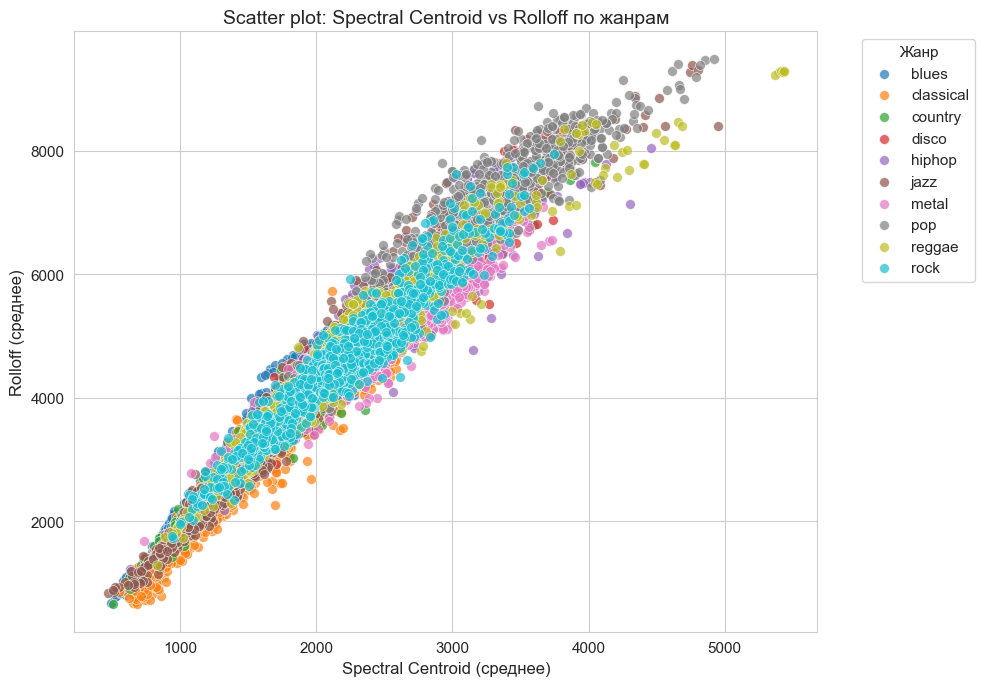

In [98]:
genres = df['label'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(genres)))
genre_colors = dict(zip(genres, colors))

fig, ax = plt.subplots(figsize=(10, 7))

for genre in genres:
    subset = df[df['label'] == genre]
    ax.scatter(
        subset['spectral_centroid_mean'],
        subset['rolloff_mean'],
        c=[genre_colors[genre]],
        label=genre,
        alpha=0.7,
        edgecolors='white',
        linewidth=0.5,
        s=50
    )

ax.set_xlabel('Spectral Centroid (среднее)', fontsize=12)
ax.set_ylabel('Rolloff (среднее)', fontsize=12)
ax.set_title('Scatter plot: Spectral Centroid vs Rolloff по жанрам', fontsize=14)
ax.legend(title='Жанр', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Интерпретация:** Наблюдается сильная положительная корреляция между spectral centroid и rolloff — чем выше спектральный центроид, тем выше частота среза. Жанры **pop, metal и hiphop** группируются в правой верхней части (высокая «яркость» звука), тогда как **classical и jazz** занимают нижний левый угол (мягкий, тёплый тембр с преобладанием низких и средних частот). **Rock** разбросан по всему диапазону — жанр ранородный по тембру.

### 1.2. Столбчатая диаграмма средних значений признаков по жанрам

Построим сгруппированную столбчатую диаграмму средних значений ключевых аудиопризнаков по жанрам, чтобы увидеть, какие признаки лучше всего различают жанры.

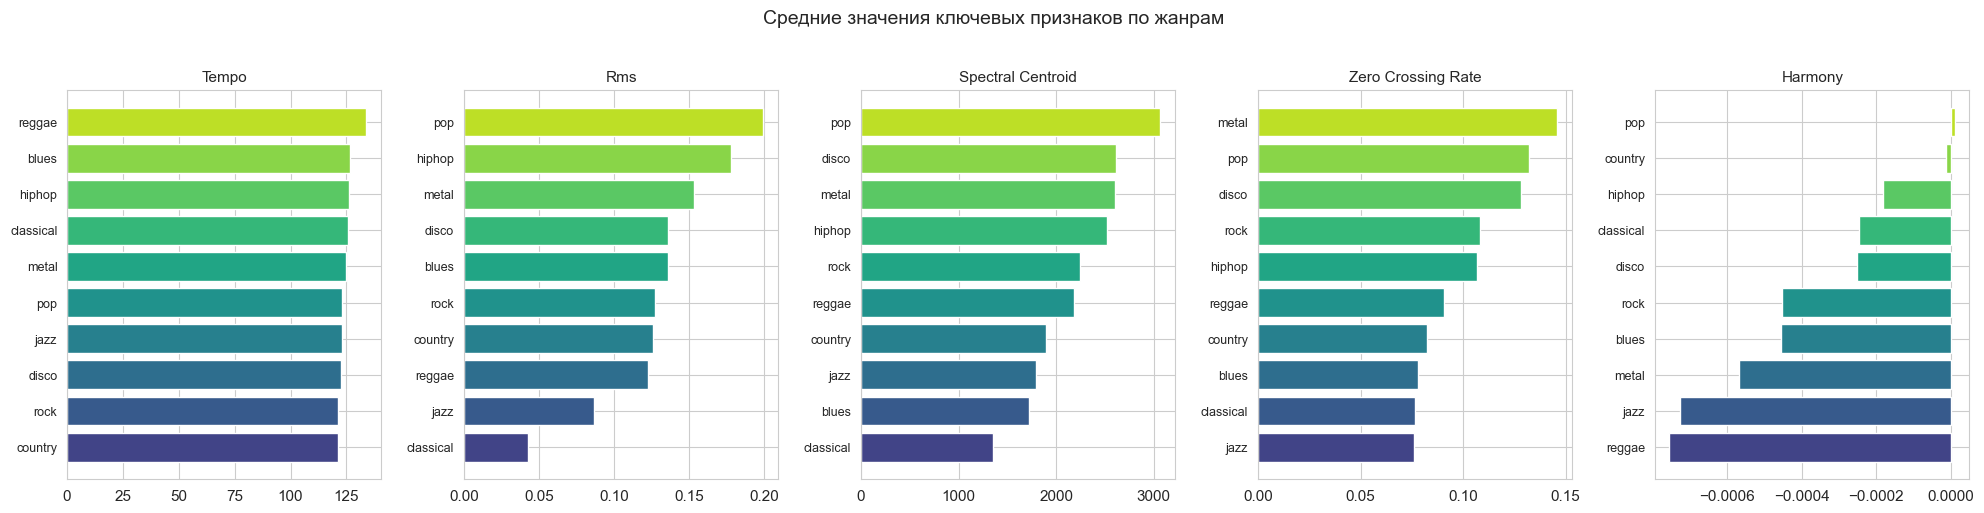

In [99]:
key_features = ['tempo', 'rms_mean', 'spectral_centroid_mean',
                'zero_crossing_rate_mean', 'harmony_mean']

means = df.groupby('label')[key_features].mean()

fig, axes = plt.subplots(1, len(key_features), figsize=(20, 5))

for i, feat in enumerate(key_features):
    sorted_means = means[feat].sort_values(ascending=True)
    bars = axes[i].barh(sorted_means.index, sorted_means.values, color=plt.cm.viridis(
        np.linspace(0.2, 0.9, len(sorted_means))))
    axes[i].set_title(feat.replace('_mean', '').replace('_', ' ').title(), fontsize=11)
    axes[i].tick_params(axis='y', labelsize=9)

fig.suptitle('Средние значения ключевых признаков по жанрам', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Интерпретация:** Каждый признак по-разному разделяет жанры. Например, tempo выше всего у reggue и blues, RMS (громкость) максимальна у pop и hiphop, а harmony более выражена у reggue и jazz.

### Замечание: GTZAN ≠ реальность

**Tempo** в датасете не всегда отражает реальные BPM жанра:
- **Reggae** — в жизни один из самых медленных жанров (60–90 BPM), а в GTZAN он в топе (~130). Причина: librosa **удваивает темп** при сложной off-beat-ритмике
- **Metal** в реальности 120–180+ BPM — должен лидировать, но в датасете средний
- **Hip-hop** в реальности 85–100 BPM, в датасете завышен

**RMS (громкость)** тоже искажён:
- Pop в топе из-за современного **мастеринга с компрессией** ("loudness war"), а не из-за реальной энергии
- Записи частично **нормализованы** — измеряется не абсолютная громкость, а динамический характер

**Причины:**
1. Алгоритмы детекции темпа часто ошибаются на сложных ритмах
2. GTZAN — старый датасет (2002), разное качество записей
3. 30 секунд — случайный фрагмент, не весь трек
4. Нормализация на этапе подготовки искажает амплитуды

**Для ML это не критично** — модель учится на признаках датасета, а не на «истинных» характеристиках жанров. Но для музыковедческой интерпретации картина искажена, особенно по tempo.


### 1.3. Визуализация матрицы признаков (imshow)

Функция `imshow()` позволяет отображать двумерные данные в виде цветовой матрицы. Визуализируем средние значения всех признаков по жанрам — это даёт общую «карту» различий между жанрами.

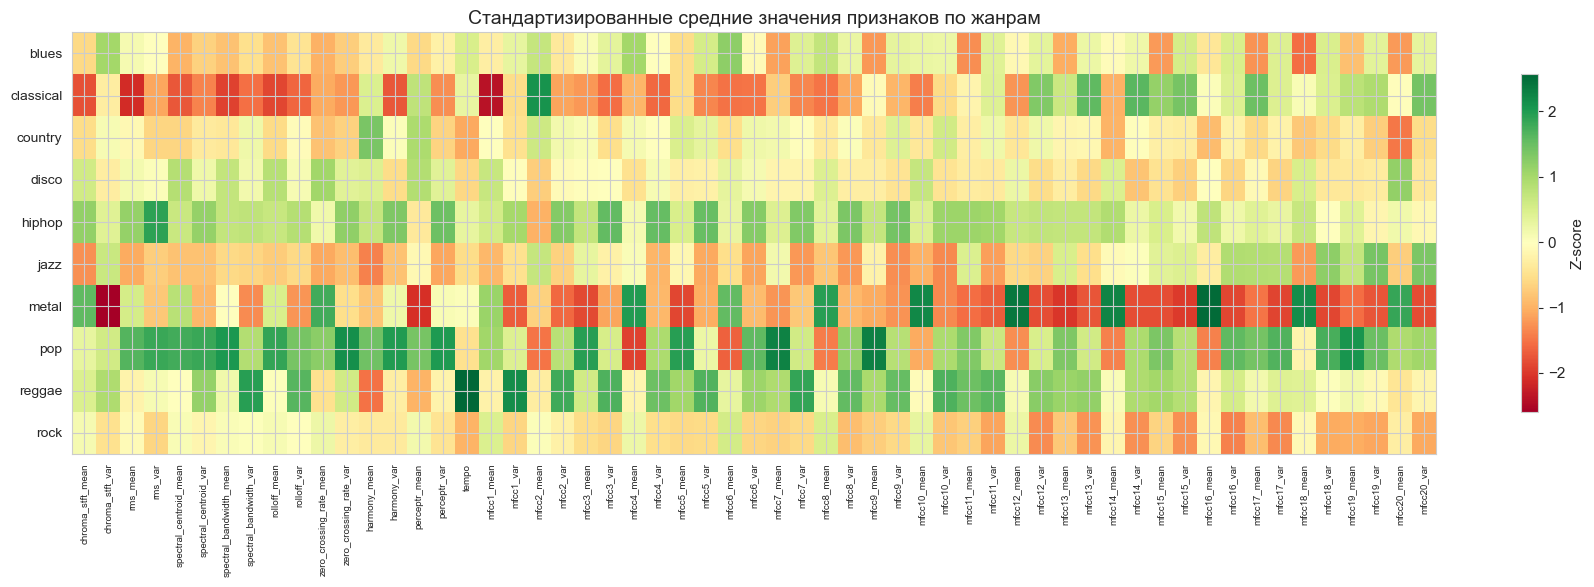

In [100]:
from sklearn.preprocessing import StandardScaler

genre_means = df.groupby('label')[numeric_cols].mean()

# Стандартизируем для сопоставимости масштабов
scaler = StandardScaler()
genre_means_scaled = pd.DataFrame(
    scaler.fit_transform(genre_means),
    index=genre_means.index,
    columns=genre_means.columns
)

fig, ax = plt.subplots(figsize=(18, 6))
im = ax.imshow(genre_means_scaled.values, cmap='RdYlGn', aspect='auto')

ax.set_yticks(range(len(genre_means_scaled.index)))
ax.set_yticklabels(genre_means_scaled.index, fontsize=10)
ax.set_xticks(range(len(genre_means_scaled.columns)))
ax.set_xticklabels(genre_means_scaled.columns, rotation=90, fontsize=7)
ax.set_title('Стандартизированные средние значения признаков по жанрам', fontsize=14)

plt.colorbar(im, ax=ax, shrink=0.8, label='Z-score')
plt.tight_layout()
plt.show()

**Интерпретация:** Матрица показывает «профили» жанров в пространстве признаков.

- **Classical** выделяется **низкими значениями** спектральных характеристик (`spectral_centroid`, `rolloff`, `zero_crossing_rate`, `rms`) — мягкий, низкочастотный, тихий звук. При этом имеет **высокие значения MFCC** (особенно MFCC 1–10).
- **Pop** — наоборот, лидер по спектральным и энергетическим характеристикам (яркий, громкий, насыщенный звук).
- **Metal** выделяется **отрицательными MFCC-коэффициентами** и высоким `zero_crossing_rate` (шумный, высокочастотный звук с большой энергией на высоких частотах).
- **Reggae и hiphop** имеют характерные профили с высокими `rms` и средними спектральными значениями.
- **Country, disco, rock** — более «средние» профили без выраженных экстремумов, что объясняет их худшую классификацию.

---
## 2. Гистограммы распределений по всем признакам

Гистограмма показывает, сколько наблюдений попадает в каждый интервал значений. Это основной инструмент для оценки формы распределения: нормальное, скошенное, бимодальное и т.д. Наложение кривой KDE (Kernel Density Estimation) позволяет увидеть сглаженную оценку плотности.

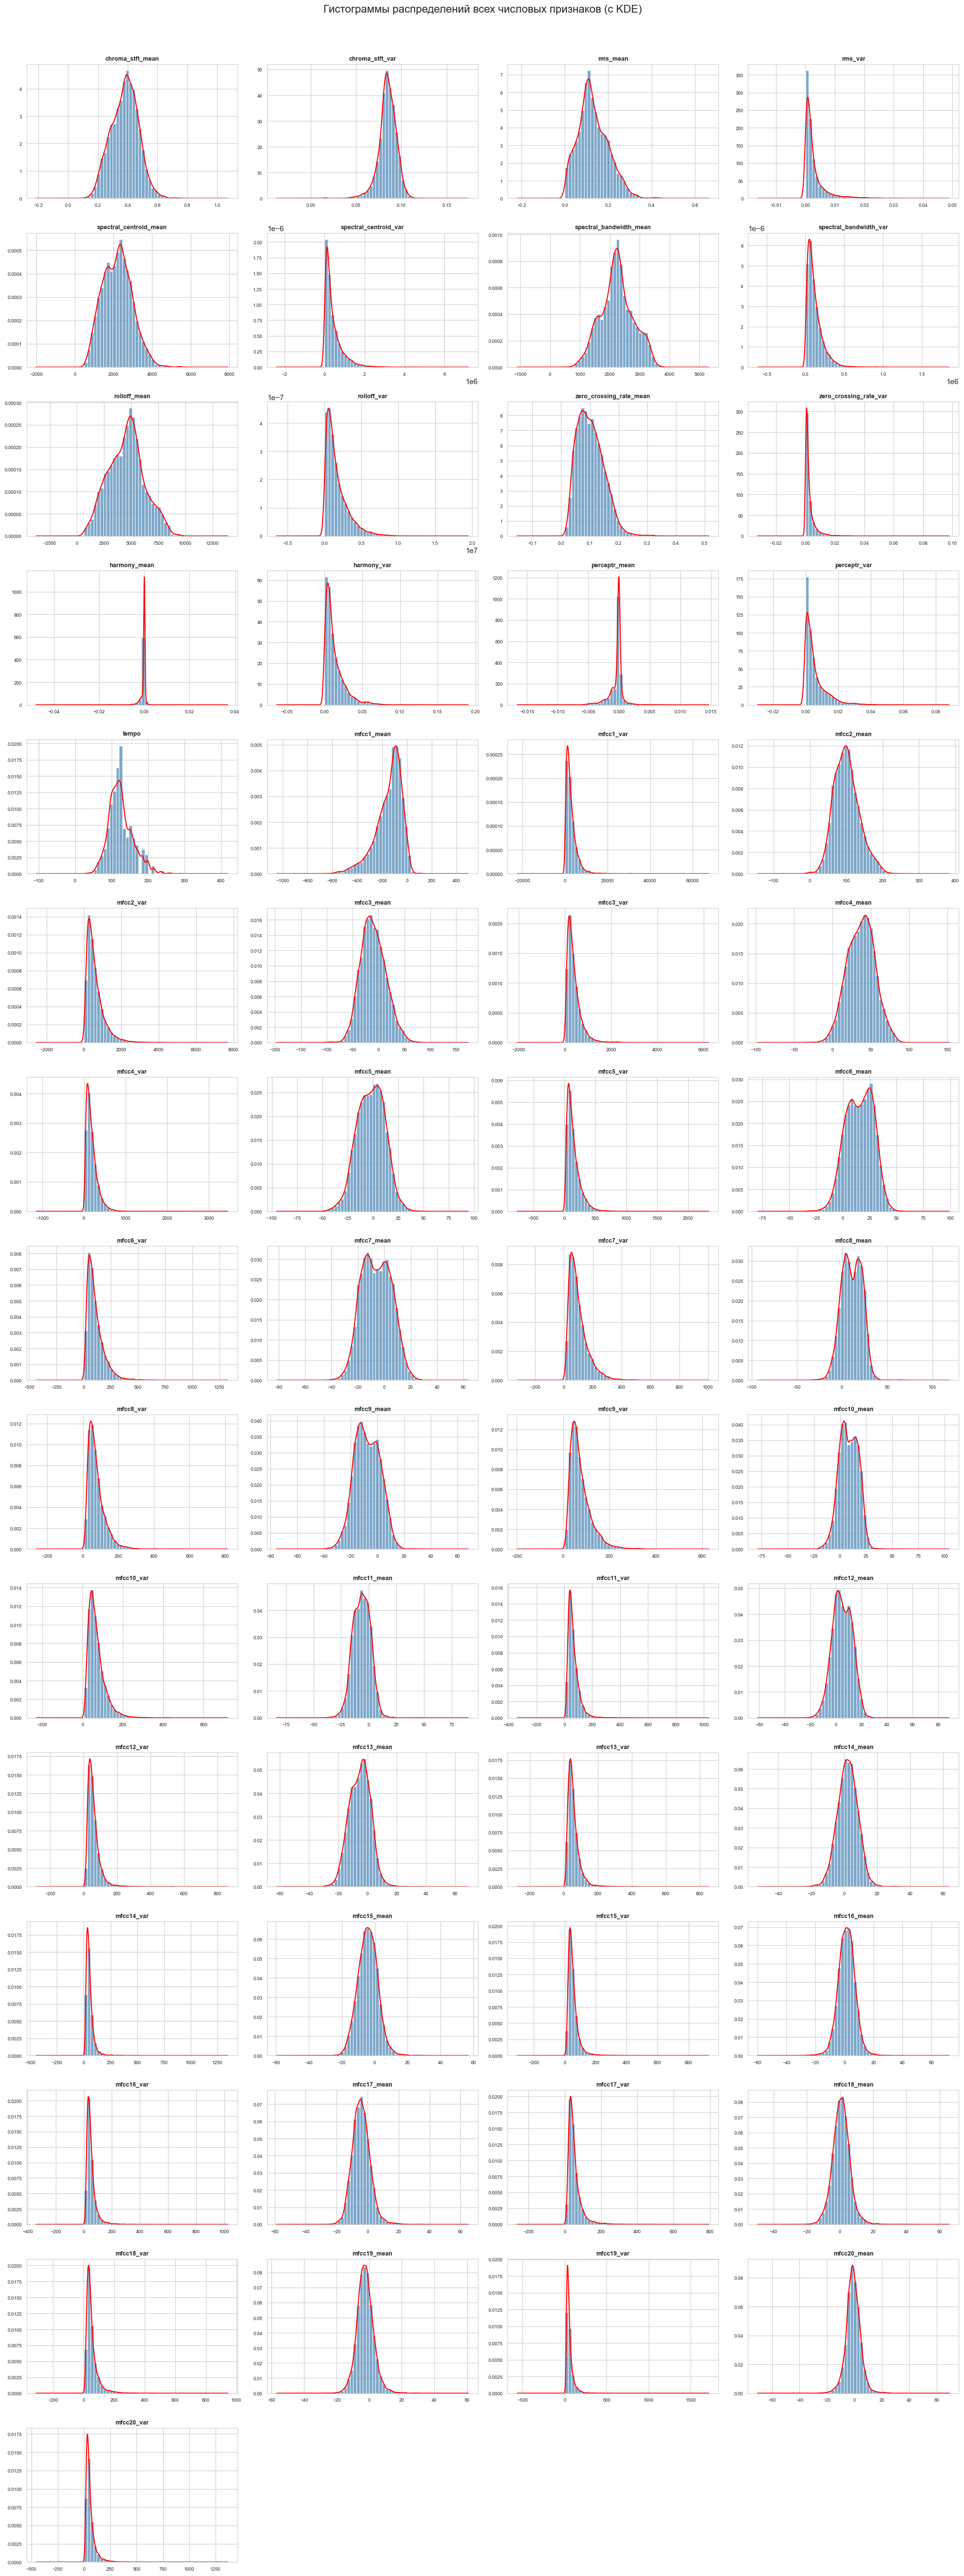

In [101]:
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white',
            alpha=0.7, density=True)
    df[col].plot.kde(ax=ax, color='red', linewidth=1.5)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.set_ylabel('')

# Скрыть пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Гистограммы распределений всех числовых признаков (с KDE)',
             fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

**Интерпретация:** Признаки распределены по-разному.

- **tempo** имеет правостороннюю асимметрию: мода около 100–120 BPM и длинный хвост до ~400.
- **harmony_mean** и **perceptr_mean** демонстрируют крайне узкий пик у нуля (очень высокий эксцесс, лептокуртичность) — большинство значений сосредоточено вблизи нуля.
- **Спектральные признаки** (`spectral_centroid_mean`, `rolloff_mean`, `zero_crossing_rate_mean`) близки к нормальным с небольшой правосторонней асимметрией.
- У ряда MFCC (`mfcc7_mean`, `mfcc8_mean`, `mfcc9_mean`, `mfcc10_mean`) заметна **бимодальность** — два пика на гистограмме. Бимодальность почти всегда означает, что в выборке смешаны две подгруппы с разными типичными значениями признака. Гипотеза: эти пики соответствуют разным группам жанров. Проверим ниже.
- Для многих признаков дисперсия (`*_var`) распределена сильно асимметрично и потребует масштабирования или логарифмирования перед обучением моделей.

### 2.1. Проверка гипотезы: бимодальность MFCC = различия между жанрами

Если два пика в гистограмме действительно соответствуют разным группам жанров, то при построении KDE **отдельно для каждого жанра** мы должны увидеть одиночные (унимодальные) распределения, центры которых разнесены — а их сумма и даёт общий бимодальный профиль.

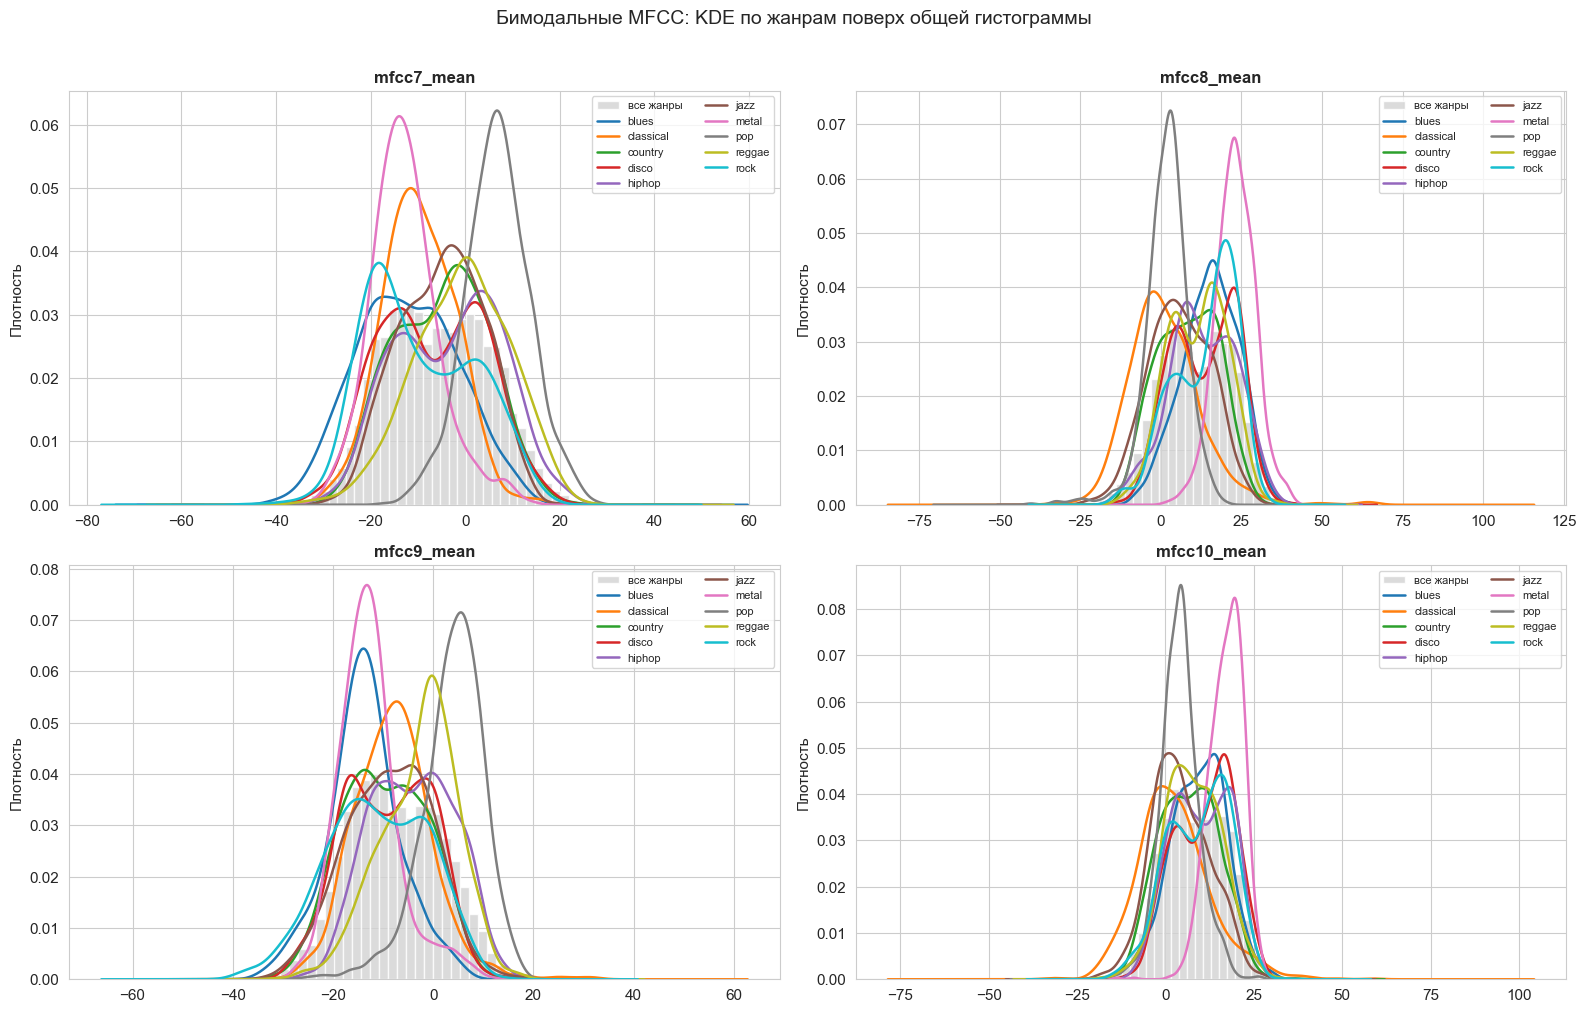

In [115]:
bimodal_mfcc = ['mfcc7_mean', 'mfcc8_mean', 'mfcc9_mean', 'mfcc10_mean']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(bimodal_mfcc):
    ax = axes[i]
    # Серый фон — общая гистограмма (как на исходном графике)
    ax.hist(df[feat], bins=40, color='lightgray', edgecolor='white',
            density=True, alpha=0.8, label='все жанры')
    # Поверх — KDE по каждому жанру отдельно
    for genre in sorted(genres):
        subset = df.loc[df['label'] == genre, feat]
        subset.plot.kde(ax=ax, label=genre, color=genre_colors[genre], linewidth=1.8)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Плотность')
    ax.legend(fontsize=8, ncol=2, loc='upper right')

fig.suptitle('Бимодальные MFCC: KDE по жанрам поверх общей гистограммы',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Дополнительно — посчитаем медианные значения каждого MFCC по жанрам, чтобы явно увидеть, какие жанры «сидят» в левом пике, а какие — в правом.

In [116]:
medians = df.groupby('label')[bimodal_mfcc].median().round(2)
# Сортируем жанры по mfcc7_mean, чтобы было видно упорядочение
medians_sorted = medians.sort_values('mfcc7_mean')
medians_sorted.style.background_gradient(cmap='RdYlGn_r', axis=0)

,mfcc7_mean,mfcc8_mean,mfcc9_mean,mfcc10_mean
label,,,,
metal,-13.410000,23.150000,-13.320000,17.630000
blues,-12.630000,15.740000,-13.690000,9.830000
rock,-11.680000,16.500000,-11.280000,10.700000
classical,-10.210000,-0.050000,-8.130000,1.630000
disco,-6.950000,14.460000,-8.830000,12.250000
jazz,-4.390000,5.550000,-8.390000,3.420000
country,-4.300000,8.840000,-9.550000,6.740000
hiphop,-2.130000,12.470000,-4.000000,9.910000
reggae,-0.060000,12.200000,-1.420000,7.630000


**Вывод проверки:**

- KDE по жанрам показывают, что **каждый жанр по отдельности имеет унимодальное распределение**. Это и есть подтверждение исходной гипотезы: бимодальность общей гистограммы — не свойство одного распределения, а **суперпозиция распределений разных жанров** с сильно разнесёнными центрами.
- По таблице медиан видно, что **направление разделения разное для разных MFCC** — единой схемы «classical слева / metal справа» нет:
  - на `mfcc7_mean` слева сидит **metal** (−13.4) вместе с blues, rock и classical, а справа выделяется **pop** (+6.7);
  - на `mfcc8_mean` слева оторван **classical** (≈0), справа — **metal** (+23) и остальные;
  - на `mfcc10_mean` наоборот: classical и jazz слева (≈2–3), **metal** — самый правый (+17.6).
- Устойчивая закономерность: **metal и pop часто занимают крайние позиции** (полярные тембрально), а **classical** обычно оторван от основной массы жанров. Благодаря этому жанровые «облака» плохо перекрываются на этих MFCC.
- Практический вывод: MFCC 7–10 — сильные разделяющие признаки. Для линейных моделей это хорошо (большое межклассовое расстояние), для методов с допущением о нормальности распределения целевой переменной (например, GaussianNB по всей выборке без разбиения на классы) — напоминание, что такое допущение нарушено.

---
## 3. Ящик с усами (Boxplot) для выявления выбросов

**Box plot** (ящик с усами) — один из ключевых инструментов описательной статистики. Он одновременно показывает медиану, межквартильный размах (IQR), «усы» (1.5*IQR от границ ящика) и выбросы (точки за пределами усов). Построим boxplot для ключевых признаков в разбивке по жанрам.

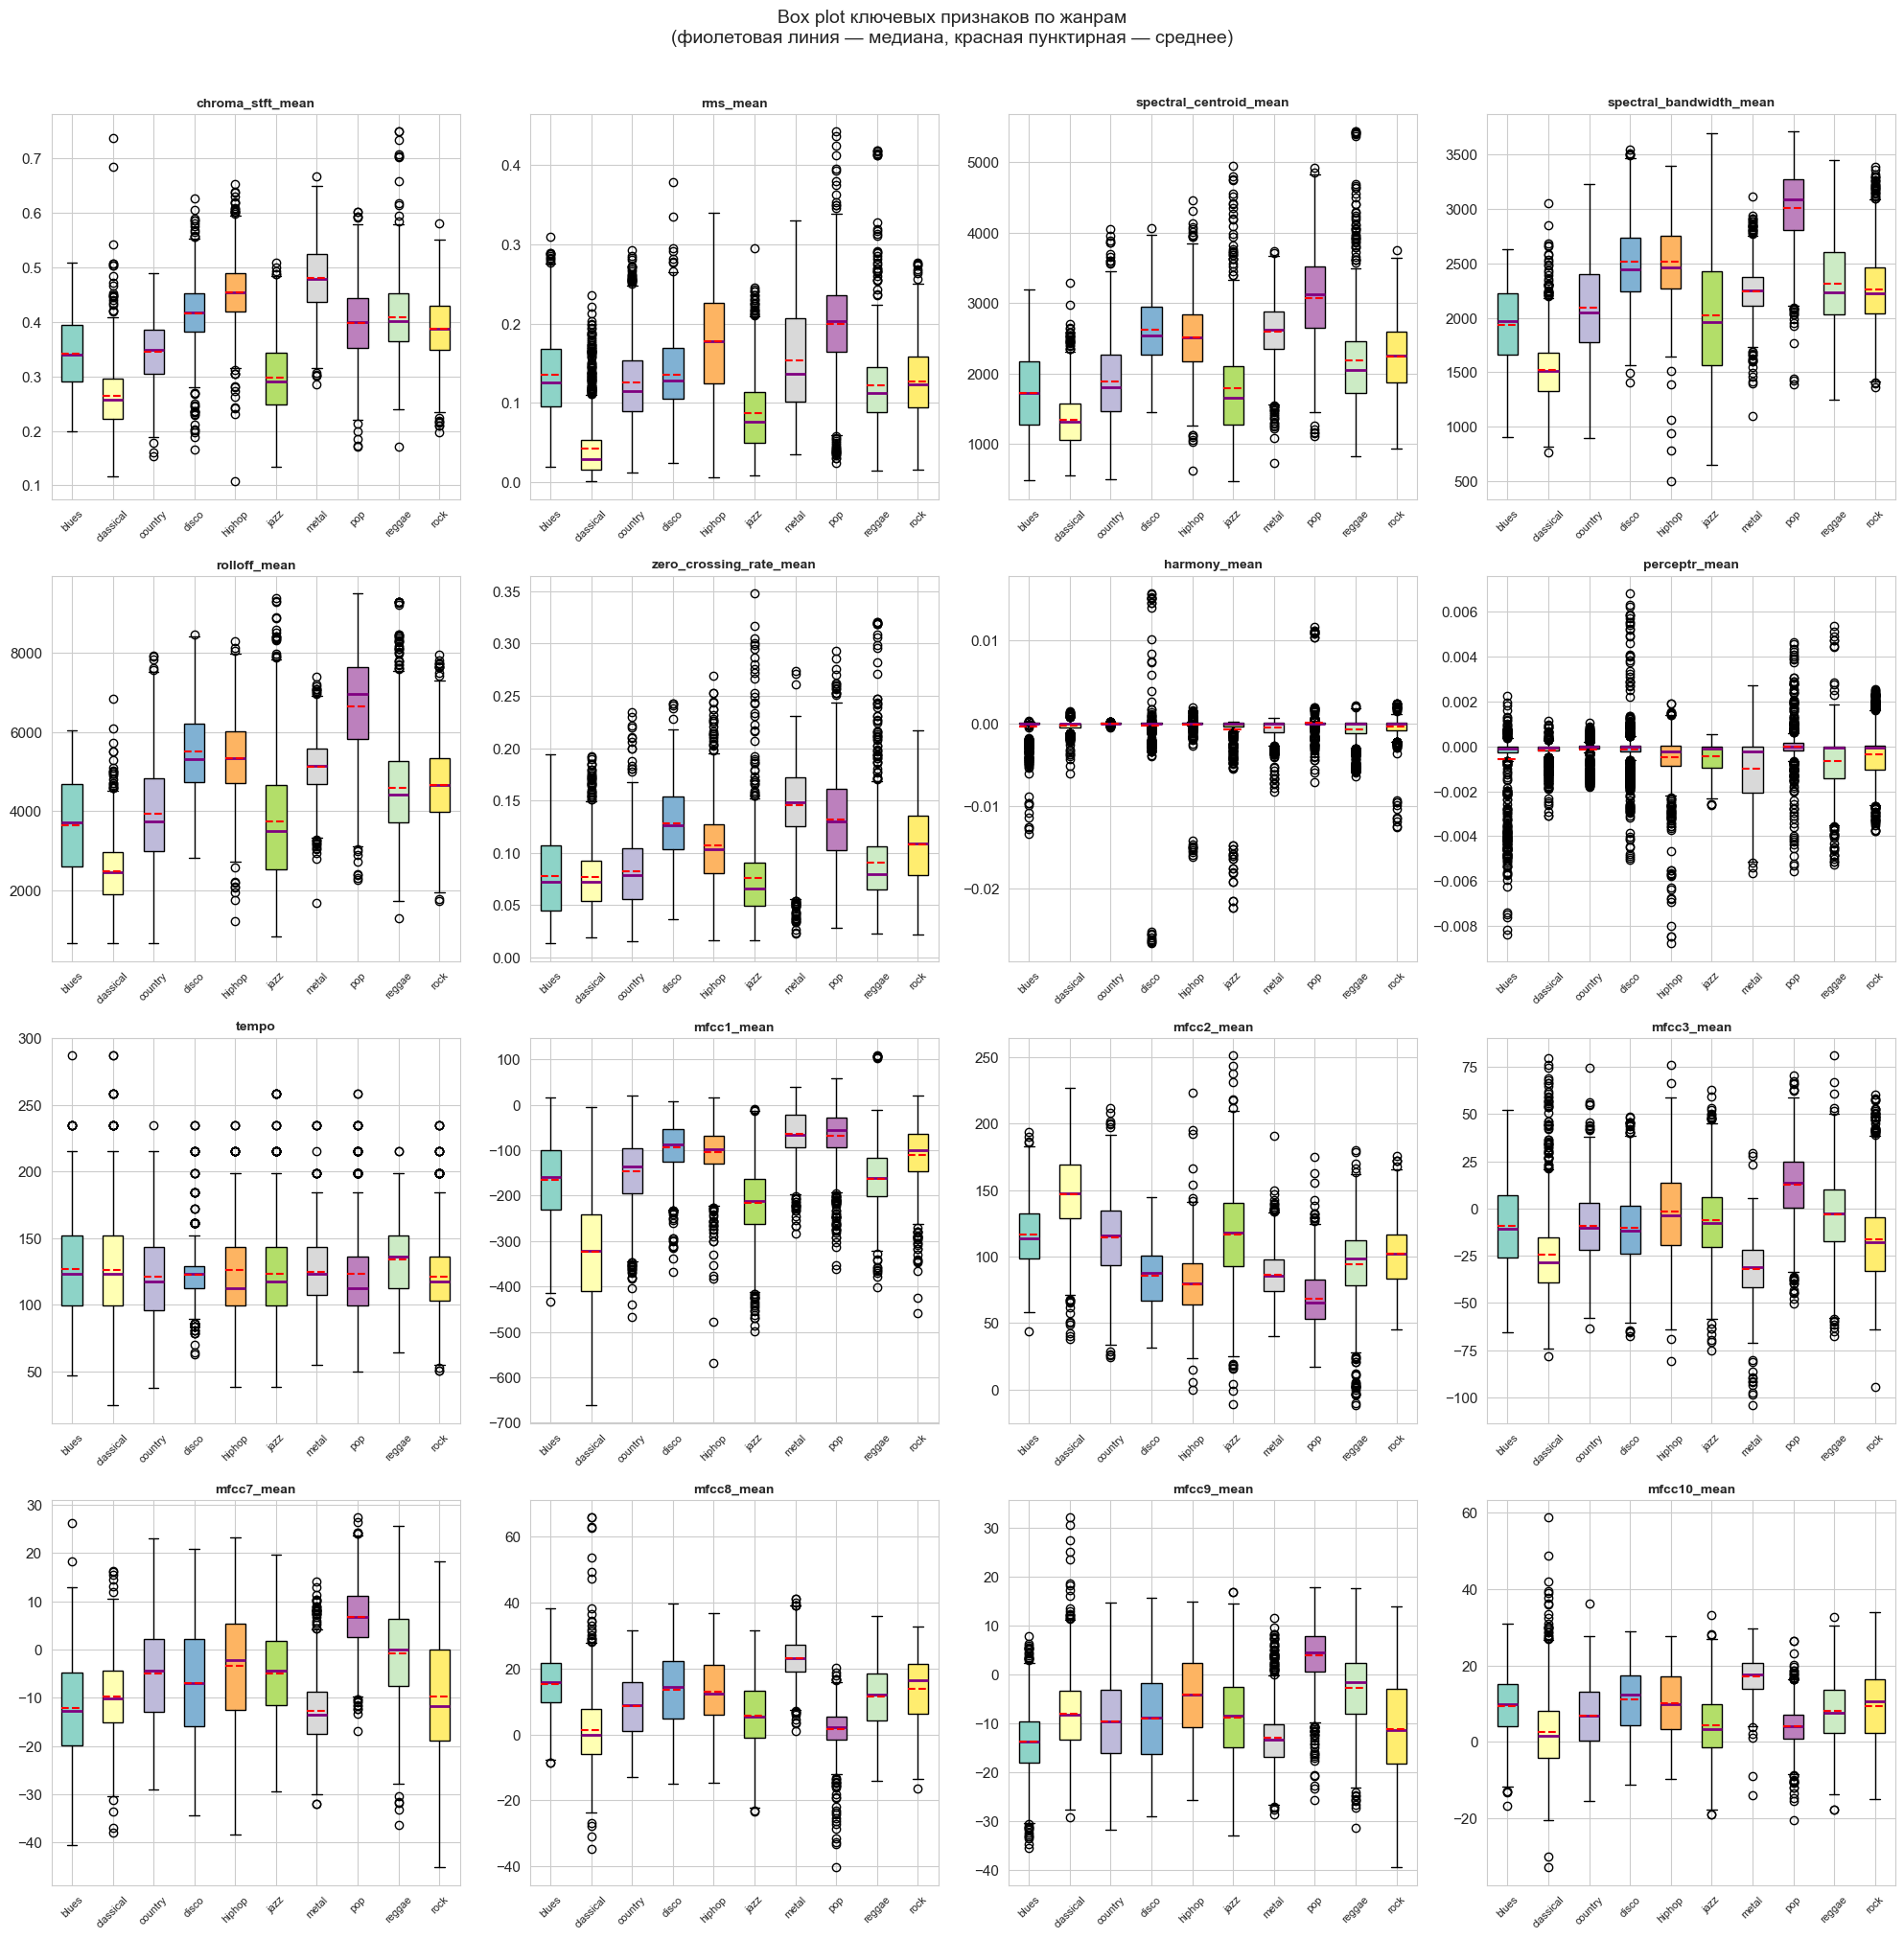

In [104]:
boxplot_features = [
    'chroma_stft_mean', 'rms_mean', 'spectral_centroid_mean',
    'spectral_bandwidth_mean', 'rolloff_mean', 'zero_crossing_rate_mean',
    'harmony_mean', 'perceptr_mean', 'tempo',
    'mfcc1_mean', 'mfcc2_mean', 'mfcc3_mean',
    'mfcc7_mean', 'mfcc8_mean', 'mfcc9_mean', 'mfcc10_mean'
]

n_cols = 4
n_rows = (len(boxplot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, feat in enumerate(boxplot_features):
    ax = axes[i]
    data_by_genre = [df[df['label'] == g][feat].values for g in sorted(genres)]
    bp = ax.boxplot(data_by_genre, labels=sorted(genres), patch_artist=True,
                    showmeans=True, meanline=True,
                    medianprops={'linewidth': 2, 'color': 'purple'},
                    meanprops={'linewidth': 1.5, 'color': 'red', 'linestyle': '--'})

    palette = plt.cm.Set3(np.linspace(0, 1, len(genres)))
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)

    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

# Скрыть пустые ячейки
for j in range(len(boxplot_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Box plot ключевых признаков по жанрам\n'
             '(фиолетовая линия — медиана, красная пунктирная — среднее)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Интерпретация:** Box plot'ы выявляют множество выбросов (точки за пределами усов). Жанр metal выделяется высокими значениями rms_mean, spectral_centroid_mean и rolloff_mean. Classical имеет наибольший разброс в harmony_mean. Tempo содержит выбросы во всех жанрах, так как ритмическая структура произведений внутри одного жанра может существенно различаться.

---
## 4. Тепловая карта корреляций (Seaborn)

Seaborn — высокоуровневая надстройка над Matplotlib, которая упрощает построение статистических графиков. Тепловая карта корреляционной матрицы позволяет одним взглядом оценить, какие признаки сильно связаны друг с другом, а какие — нет.

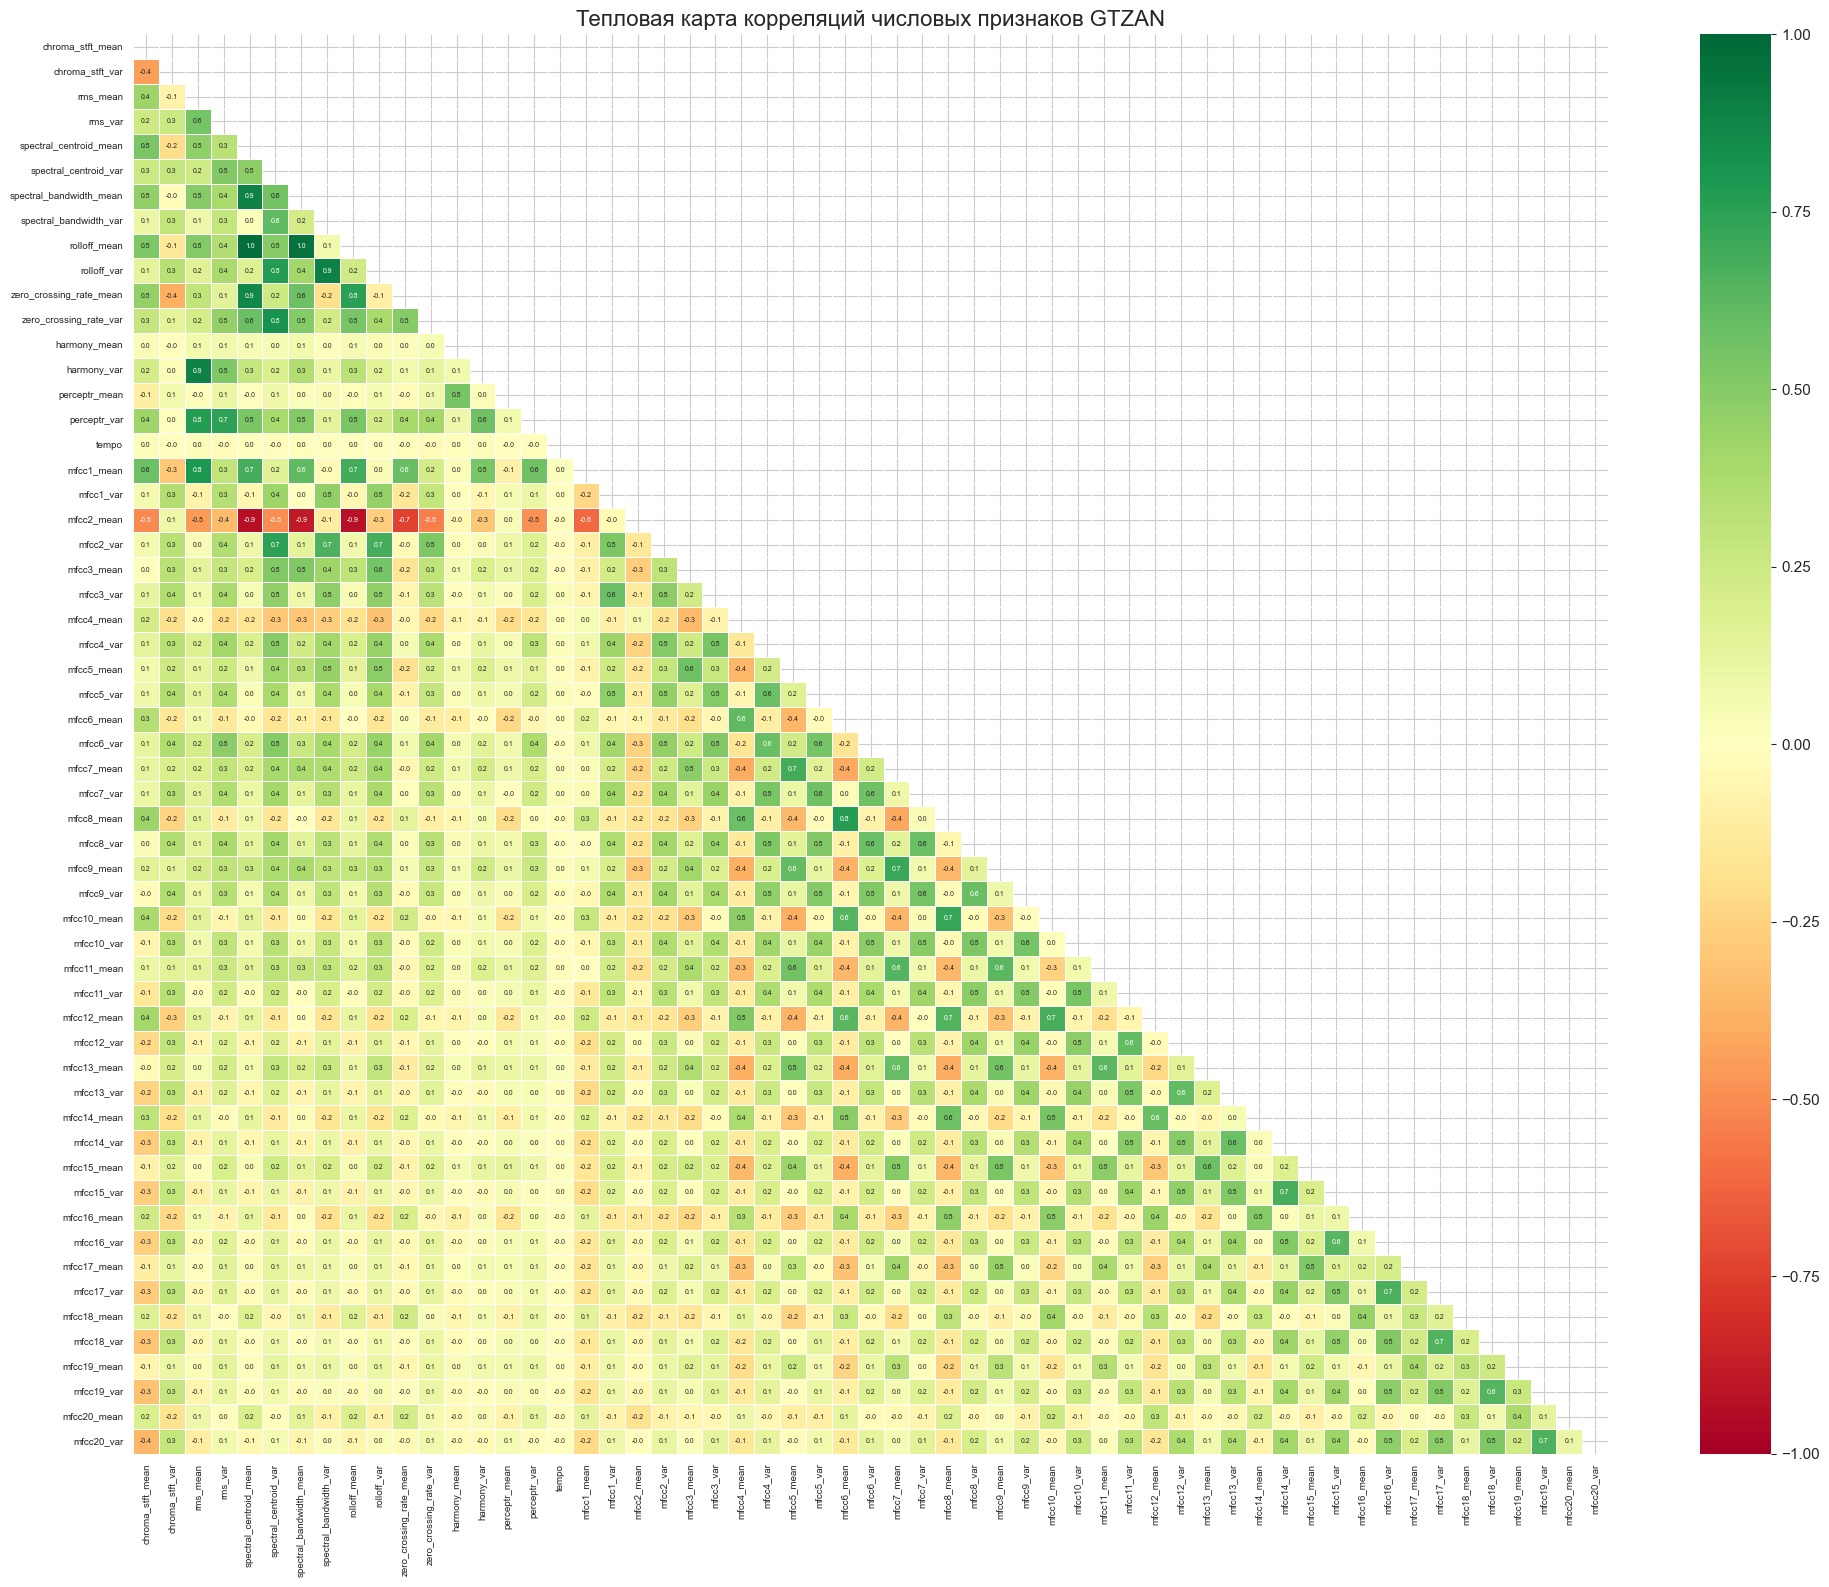

In [105]:
corr_matrix = df[numeric_cols].corr()

# Показываем только нижний треугольник, чтобы избежать дублирования
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 5},
    ax=ax,
    vmin=-1,
    vmax=1
)
ax.set_title('Тепловая карта корреляций числовых признаков GTZAN', fontsize=16)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

### Выводы по корреляционной матрице

Из тепловой карты можно выделить несколько групп сильно скоррелированных признаков:

1. **spectral_centroid_mean, spectral_bandwidth_mean, rolloff_mean** (корреляция > 0.8) — все три описывают «яркость» спектра, что логично.
2. **Пары mean/var** одного и того же признака часто коррелируют, но не всегда — это означает, что дисперсия несёт дополнительную информацию о стабильности признака во времени.
3. **MFCC-признаки** слабо коррелируют друг с другом, что делает их ценными для ML-моделей (меньше мультиколлинеарности).
4. **perceptr_mean и harmony_mean** имеют отрицательную корреляцию — чем выше гармоничность, тем ниже перкуссионная составляющая.

Высококоррелированные признаки (>0.9) могут быть кандидатами на удаление при отборе признаков, чтобы избежать мультиколлинеарности в линейных моделях.

### Топ-10 пар признаков с наибольшей корреляцией

In [106]:
# Извлекаем уникальные пары с наибольшей корреляцией
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Признак 1', 'Признак 2', 'Корреляция']
corr_pairs['|Корреляция|'] = corr_pairs['Корреляция'].abs()
corr_pairs.sort_values('|Корреляция|', ascending=False).head(10).drop(columns='|Корреляция|')

,Признак 1,Признак 2,Корреляция
221,spectral_centroid_mean,rolloff_mean,0.974360
322,spectral_bandwidth_mean,rolloff_mean,0.951000
232,spectral_centroid_mean,mfcc2_mean,-0.931435
430,rolloff_mean,mfcc2_mean,-0.923652
372,spectral_bandwidth_var,rolloff_var,0.891339
219,spectral_centroid_mean,spectral_bandwidth_mean,0.890382
333,spectral_bandwidth_mean,mfcc2_mean,-0.887156
121,rms_mean,harmony_var,0.884846
223,spectral_centroid_mean,zero_crossing_rate_mean,0.865487
275,spectral_centroid_var,zero_crossing_rate_var,0.818348


---
## 5. Продвинутые визуализации Seaborn

### 5.1. Violin plot — распределения по жанрам

Violin plot сочетает информацию box plot и KDE-оценки плотности. Внутри «скрипки» показана медиана и квартили, а форма отражает плотность распределения на каждом уровне значения.

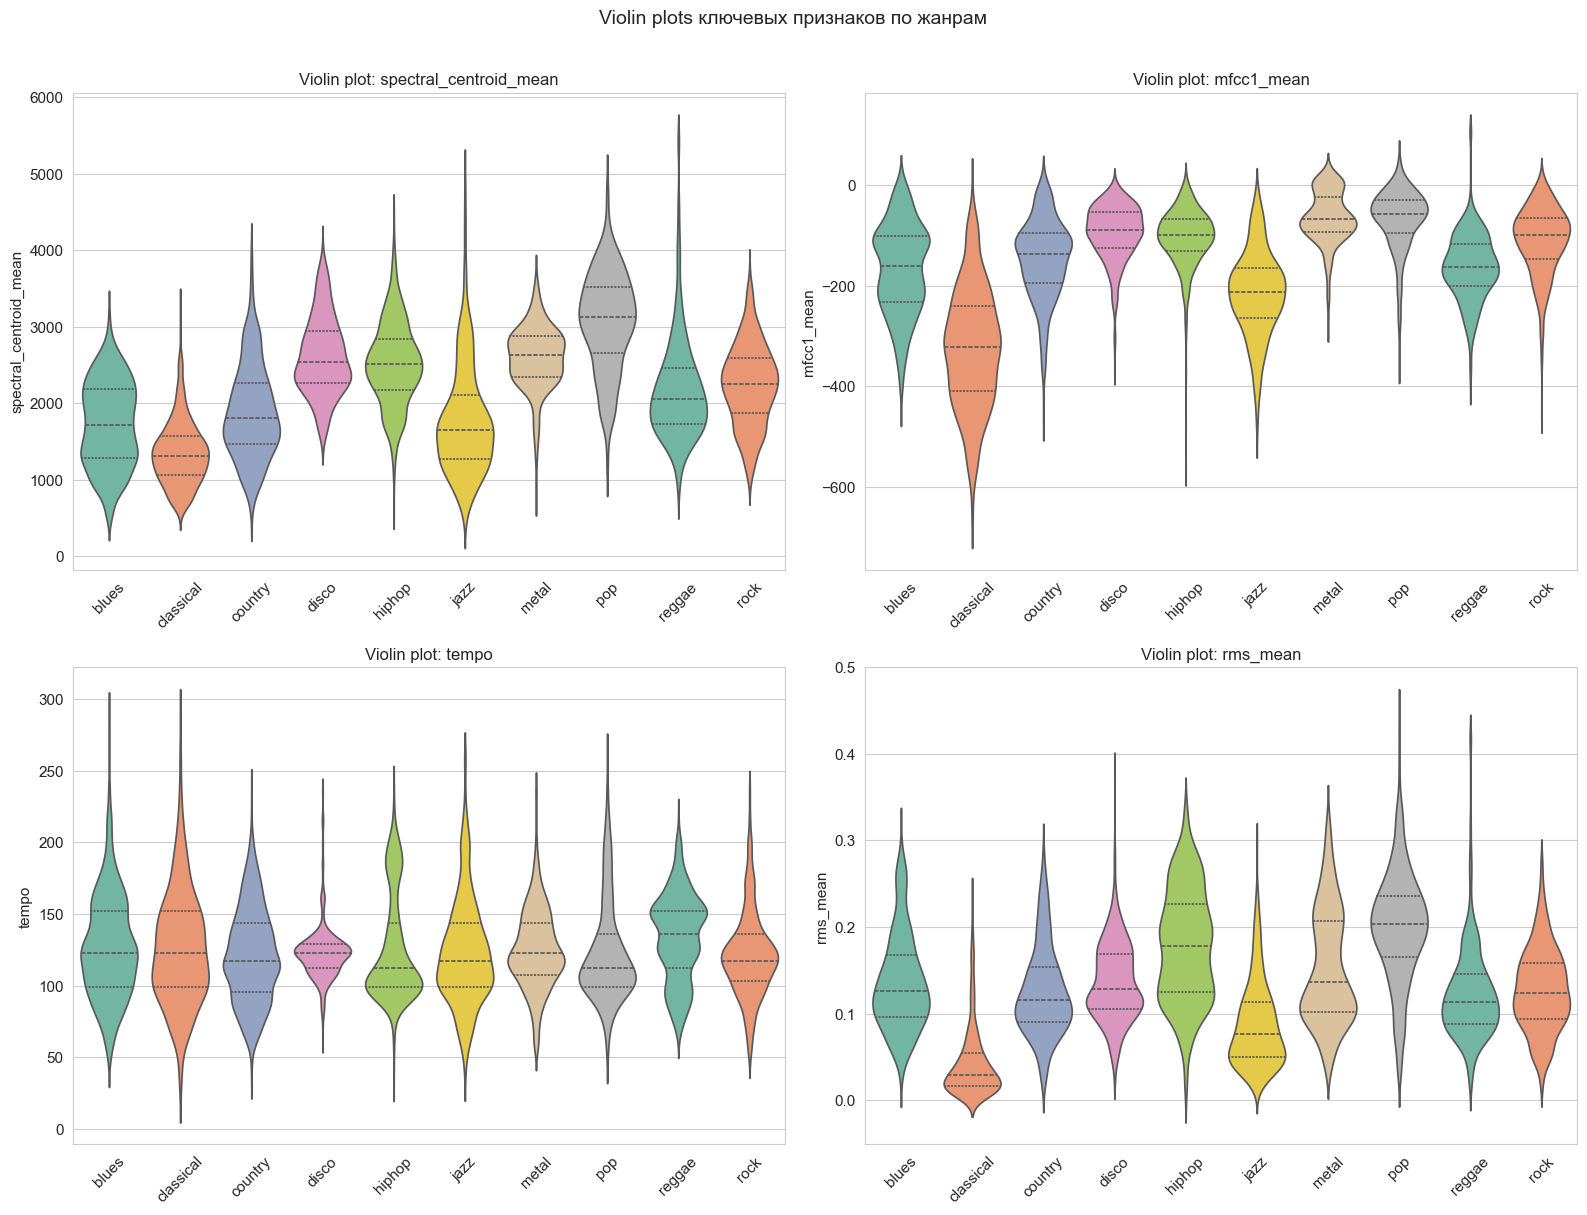

In [107]:
violin_features = ['spectral_centroid_mean', 'mfcc1_mean', 'tempo', 'rms_mean']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(violin_features):
    sns.violinplot(
        data=df, x='label', y=feat,
        palette='Set2', inner='quartile', ax=axes[i]
    )
    axes[i].set_title(f'Violin plot: {feat}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle('Violin plots ключевых признаков по жанрам', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Интерпретация:** Violin plot показывает, что для spectral_centroid_mean classical имеет узкое, компактное распределение в нижнем диапазоне, а metal — широкое в верхнем. MFCC1 демонстрирует чёткое разделение: отрицательные значения у classical и jazz, положительные у hiphop и reggae.

### 5.2. Pair plot — парные зависимости ключевых признаков

Pairplot строит scatter plot для каждой пары признаков и гистограмму для каждого признака на диагонали. Это позволяет одновременно оценить распределения и взаимозависимости.

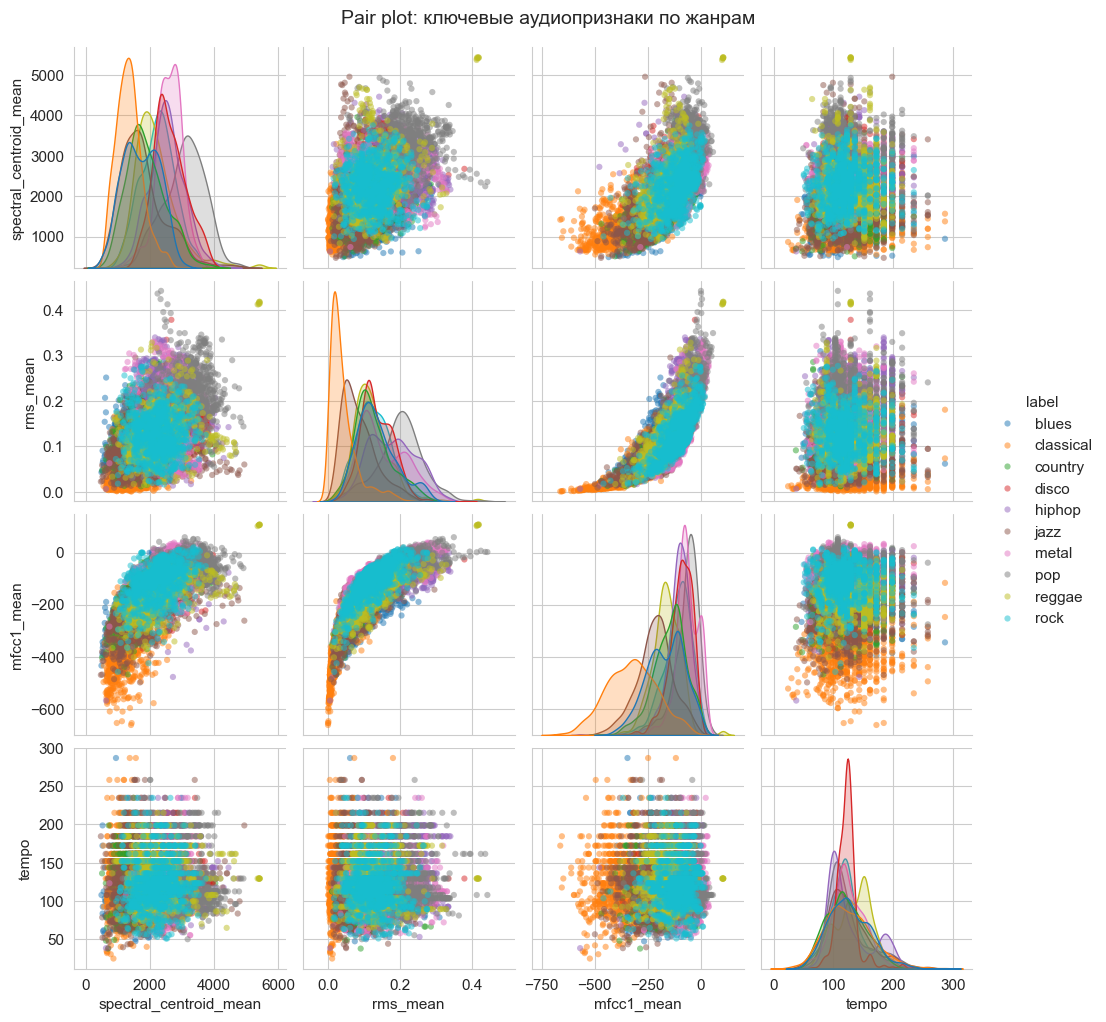

In [108]:
pair_features = ['spectral_centroid_mean', 'rms_mean', 'mfcc1_mean', 'tempo', 'label']

g = sns.pairplot(
    df[pair_features],
    hue='label',
    palette='tab10',
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 20, 'edgecolor': 'none'},
    height=2.5
)
g.figure.suptitle('Pair plot: ключевые аудиопризнаки по жанрам', y=1.02, fontsize=14)
plt.show()

**Интерпретация:** Pairplot подтверждает, что комбинация spectral_centroid_mean и rms_mean хорошо разделяет жанры metal и classical. MFCC1 также является дискриминативным признаком. Tempo показывает наибольшее перекрытие между жанрами.

---
## 6. Интерактивные визуализации с Plotly

Plotly позволяет создавать интерактивные графики с hover-подсказками, масштабированием и выделением. Это особенно полезно при работе с многомерными данными.

### 6.1. Интерактивный scatter plot

In [109]:
fig = px.scatter(
    df, x='tempo', y='spectral_centroid_mean',
    color='label',
    hover_data=['rms_mean', 'mfcc1_mean', 'filename'],
    title='Интерактивный Scatter: Tempo vs Spectral Centroid',
    labels={
        'tempo': 'Темп (BPM)',
        'spectral_centroid_mean': 'Spectral Centroid (среднее)',
        'label': 'Жанр'
    },
    opacity=0.7
)
fig.update_layout(width=900, height=600)
fig.show()

### 6.2. Столбчатая диаграмма (Bar chart)

In [110]:
genre_counts = df['label'].value_counts().sort_values(ascending=True)

fig = go.Figure(go.Bar(
    x=genre_counts.values,
    y=genre_counts.index,
    orientation='h',
    marker_color=px.colors.qualitative.Set2[:len(genre_counts)],
    text=genre_counts.values,
    textposition='outside'
))

fig.update_layout(
    title='Количество записей по жанрам',
    xaxis_title='Количество',
    yaxis_title='Жанр',
    width=700, height=450
)
fig.show()

### 6.3. Интерактивный Box plot

In [111]:
fig = px.box(
    df, x='label', y='spectral_centroid_mean',
    color='label',
    title='Box plot: Spectral Centroid Mean по жанрам (Plotly)',
    labels={'label': 'Жанр', 'spectral_centroid_mean': 'Spectral Centroid (среднее)'},
    points='outliers'
)
fig.update_layout(width=900, height=500, showlegend=False)
fig.show()

### 6.4. Интерактивная гистограмма

In [112]:
fig = px.histogram(
    df, x='tempo', color='label',
    nbins=40, barmode='overlay',
    opacity=0.6,
    title='Гистограмма: распределение темпа по жанрам',
    labels={'tempo': 'Темп (BPM)', 'label': 'Жанр'}
)
fig.update_layout(width=900, height=500)
fig.show()

### 6.5. Круговая диаграмма (Pie chart)

In [113]:
genre_counts_all = df['label'].value_counts()

fig = go.Figure(go.Pie(
    labels=genre_counts_all.index,
    values=genre_counts_all.values,
    hole=0.3,
    textinfo='label+percent',
    marker=dict(colors=px.colors.qualitative.Set3)
))
fig.update_layout(
    title='Доли жанров в датасете GTZAN',
    width=650, height=500
)
fig.show()

**Интерпретация Plotly-визуализаций:** Датасет GTZAN сбалансирован — каждый жанр представлен 100 записями (по 10%). Интерактивность Plotly позволяет детально исследовать каждую точку данных, что невозможно в статичных графиках Matplotlib.

---
## 7. Визуализация через Pandas .plot()

Метод `.plot()` в Pandas — это обёртка над Matplotlib, позволяющая строить графики прямо из DataFrame/Series. Удобство в том, что не нужно отдельно передавать x и y — Pandas использует индекс и столбцы автоматически.

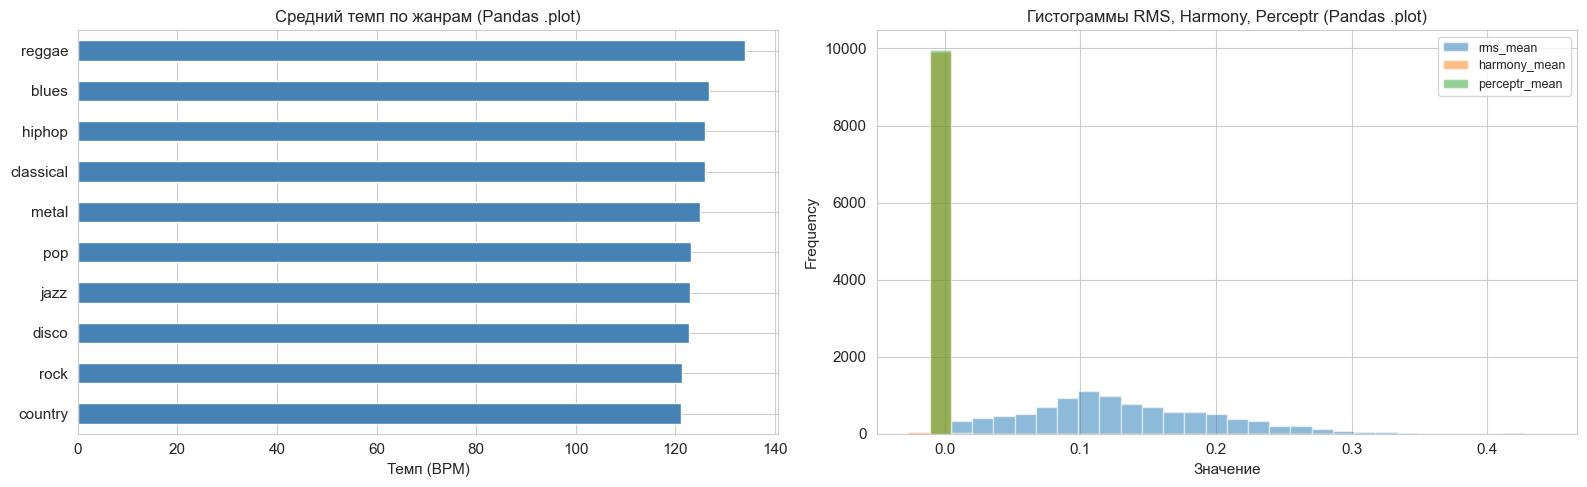

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar plot через pandas
df.groupby('label')['tempo'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Средний темп по жанрам (Pandas .plot)', fontsize=12)
axes[0].set_xlabel('Темп (BPM)')
axes[0].set_ylabel('')

# Гистограмма через pandas
df[['rms_mean', 'harmony_mean', 'perceptr_mean']].plot(
    kind='hist', bins=30, alpha=0.5, ax=axes[1], edgecolor='white'
)
axes[1].set_title('Гистограммы RMS, Harmony, Perceptr (Pandas .plot)', fontsize=12)
axes[1].set_xlabel('Значение')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Интерпретация:** Pandas .plot() позволяет быстро строить графики с минимумом кода. Метод удобен для экспресс-анализа, но для тонкой настройки оформления всё равно потребуется Matplotlib API.

---
## Выводы

В ходе лабораторной работы мы освоили три основных инструмента визуализации данных в Python и применили их к аудиодатасету GTZAN:

### Основные результаты:

1. **Matplotlib** предоставляет полный контроль над каждым элементом графика. Мы построили scatter plot, столбчатые диаграммы и матричные визуализации (imshow), которые показали чёткие различия между жанрами по спектральным признакам.

2. **Гистограммы** распределений выявили, что большинство аудиопризнаков имеют унимодальное распределение различной степени асимметрии, а некоторые MFCC-коэффициенты демонстрируют бимодальность.

3. **Box plot'ы** позволили обнаружить выбросы во всех признаках, а также показали, что такие жанры как metal и classical наиболее «отделимы» от остальных по спектральным характеристикам.

4. **Тепловая карта корреляций** (Seaborn) выявила группы высококоррелированных признаков (spectral_centroid, rolloff, bandwidth), что важно для последующего отбора признаков.

5. **Violin plot и pairplot** (Seaborn) дали более детальное представление о распределениях внутри жанров и подтвердили, что комбинация spectral_centroid + rms + mfcc1 хорошо разделяет жанры.

6. **Plotly** обеспечил интерактивность: hover-подсказки с информацией о каждой записи, масштабирование и выделение отдельных жанров.

7. **Pandas .plot()** продемонстрировал удобный способ быстрого построения графиков прямо из DataFrame.

### Практическое значение:

Проведённый визуальный анализ сформировал понимание структуры данных и выявил признаки, наиболее полезные для задачи классификации жанров. Это станет основой для последующих лабораторных работ по отбору признаков и обучению моделей.